# EDA — IEEE-CIS Fraud Detection Dataset
Weeks 3–4: distributions, imbalance ratio, missing values, feature correlations.

In [1]:
import sys; sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.ieee_cis_loader import load_raw, get_label_column

train_df, test_df = load_raw()
label = get_label_column()
print(train_df.shape)
train_df[label].value_counts(normalize=True)

(590540, 434)


isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

In [2]:
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).sort_values(ascending=False)
print("Toplam feature:", len(train_df.columns))
print("\nEksik değer oranı > %50 olan feature sayısı:", (missing_pct > 50).sum())
print("\nİlk 20 en çok eksik feature:")
missing_pct.head(20)

Toplam feature: 434

Eksik değer oranı > %50 olan feature sayısı: 214

İlk 20 en çok eksik feature:


id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_03    88.768923
id_04    88.768923
D6       87.606767
id_33    87.589494
id_10    87.312290
dtype: float64

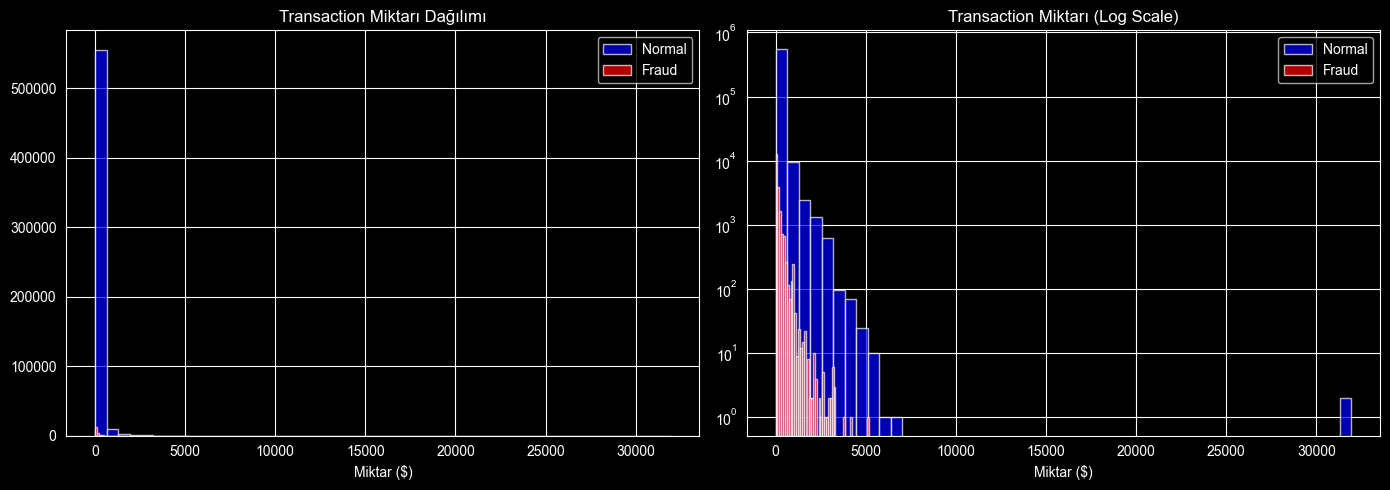

Normal - ortalama: 134.51
Fraud  - ortalama: 149.24


In [3]:
 # Transaction miktarı dağılımı (fraud vs normal)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # Normal scale
axes[0].hist(train_df[train_df[label]==0]['TransactionAmt'], bins=50, alpha=0.7,
label='Normal', color='blue')
axes[0].hist(train_df[train_df[label]==1]['TransactionAmt'], bins=50, alpha=0.7,
label='Fraud', color='red')
axes[0].set_title('Transaction Miktarı Dağılımı')
axes[0].set_xlabel('Miktar ($)')
axes[0].legend()

  # Log scale
axes[1].hist(train_df[train_df[label]==0]['TransactionAmt'], bins=50, alpha=0.7,
label='Normal', color='blue', log=True)
axes[1].hist(train_df[train_df[label]==1]['TransactionAmt'], bins=50, alpha=0.7,
label='Fraud', color='red', log=True)
axes[1].set_title('Transaction Miktarı (Log Scale)')
axes[1].set_xlabel('Miktar ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Normal - ortalama:",
train_df[train_df[label]==0]['TransactionAmt'].mean().round(2))
print("Fraud  - ortalama:",
train_df[train_df[label]==1]['TransactionAmt'].mean().round(2))

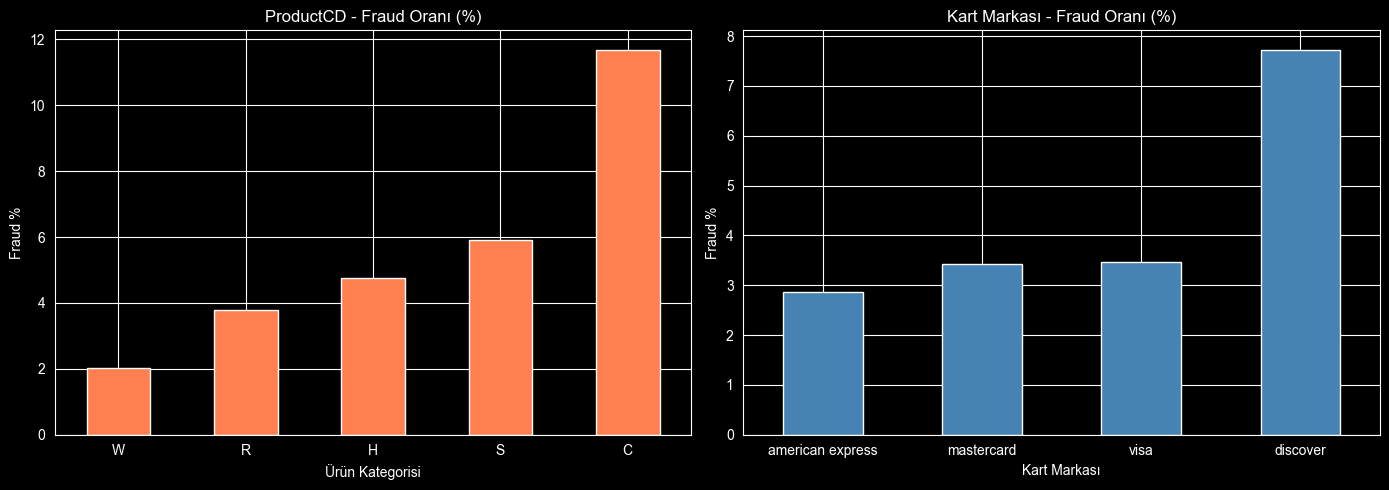

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                   
                                                                                    
fraud_by_product = train_df.groupby('ProductCD')['isFraud'].mean() * 100          
fraud_by_product.sort_values().plot(kind='bar', ax=axes[0], color='coral')        
axes[0].set_title('ProductCD - Fraud Oranı (%)')                                  
axes[0].set_xlabel('Ürün Kategorisi')                                             
axes[0].set_ylabel('Fraud %')
axes[0].tick_params(axis='x', rotation=0)

fraud_by_card4 = train_df.groupby('card4')['isFraud'].mean() * 100
fraud_by_card4.sort_values().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Kart Markası - Fraud Oranı (%)')
axes[1].set_xlabel('Kart Markası')
axes[1].set_ylabel('Fraud %')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [5]:

low_missing = missing_pct[missing_pct < 30].index.tolist()                        
high_missing = missing_pct[(missing_pct >= 30) & (missing_pct <                   
80)].index.tolist()                                                               
drop_cols = missing_pct[missing_pct >= 80].index.tolist()                         
                                                                                
print(f"Tutulacak (<%30 eksik): {len(low_missing)} feature")
print(f"Doldurulacak (%30-80 eksik): {len(high_missing)} feature")
print(f"Atılacak (>%80 eksik): {len(drop_cols)} feature")
print(f"\nAtılacak sütunlar örnek: {drop_cols[:10]}")

Tutulacak (<%30 eksik): 202 feature
Doldurulacak (%30-80 eksik): 158 feature
Atılacak (>%80 eksik): 74 feature

Atılacak sütunlar örnek: ['id_24', 'id_25', 'id_07', 'id_08', 'id_21', 'id_26', 'id_27', 'id_23', 'id_22', 'dist2']


In [6]:
train_clean = train_df.drop(columns=drop_cols).copy()                             
                                                                              
num_cols = [c for c in train_clean.select_dtypes(include=['float64',
'int64']).columns if c != 'isFraud']
cat_cols = train_clean.select_dtypes(include=['str']).columns.tolist()

for col in num_cols:
  train_clean[col] = train_clean[col].fillna(train_clean[col].median())

for col in cat_cols:
  train_clean[col] = train_clean[col].fillna(train_clean[col].mode()[0])

print(f"Temiz dataset boyutu: {train_clean.shape}")
print(f"Kalan eksik değer: {train_clean.isnull().sum().sum()}")

Temiz dataset boyutu: (590540, 360)
Kalan eksik değer: 0


In [7]:
train_clean.to_csv('../data/processed/ieee_cis_train_clean.csv', index=False)
print("Kaydedildi!")

Kaydedildi!
